# Forecasting Consults & Calls

Three forecasts per hospital: a 6-month consult forecast, a 60-day daily call forecast, and the busiest hour of
day. Modeling logic lives in `src/` and is imported here; this notebook is the narrative and methodology write-up.

**Data note:** the real caselogs/calls tables weren't provided, so this runs on synthetic data generated by
`data/generate_synthetic_data.py`, matching the spec's schema and seeded with the quirks called out in the spec:
mixed time zones, a brand-new hospital, an intermittent hospital, and a bit of messy/unjoinable data. Swapping in
real CSVs of the same shape is all that's needed to run this on production data.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader, consult_forecast, call_forecast, busiest_hour, backtest, pipeline

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
COLOR_HIST, COLOR_FCAST = "#2f4b7c", "#d1495b"


## Data: joins and time zones

All raw timestamps are UTC, but day/hour boundaries only make sense in the hospital's local time zone (a 2am UTC
call is still last night for an Eastern hospital). `src/data_loader.py` converts every row to local time using
`facilities.timeZone` before any bucketing happens, and logs + drops the small fraction of rows that can't be
joined to a known facility (missing facility on a caselog, or a call whose case has no facility).


In [2]:
tables = data_loader.load_raw_tables("../data/raw")
for name, df in tables.items():
    print(f"{name:12s} {len(df):>7,d} rows")

caselogs_local = data_loader.clean_caselogs(tables)
calls_local = data_loader.clean_calls_with_facility(tables)


facilities        10 rows
doctors           30 rows
caselogs      54,385 rows
calls        110,929 rows
schedules      1,918 rows
[data_loader] dropped 1077 caselogs with missing/unknown facility (2.0% of rows)
[data_loader] dropped 4313 calls with no matching case/facility (3.9% of rows)


## Hospitals are not alike

Volume, history length, and pattern shape vary a lot by hospital, which is why the models below are tiered rather
than one-size-fits-all.


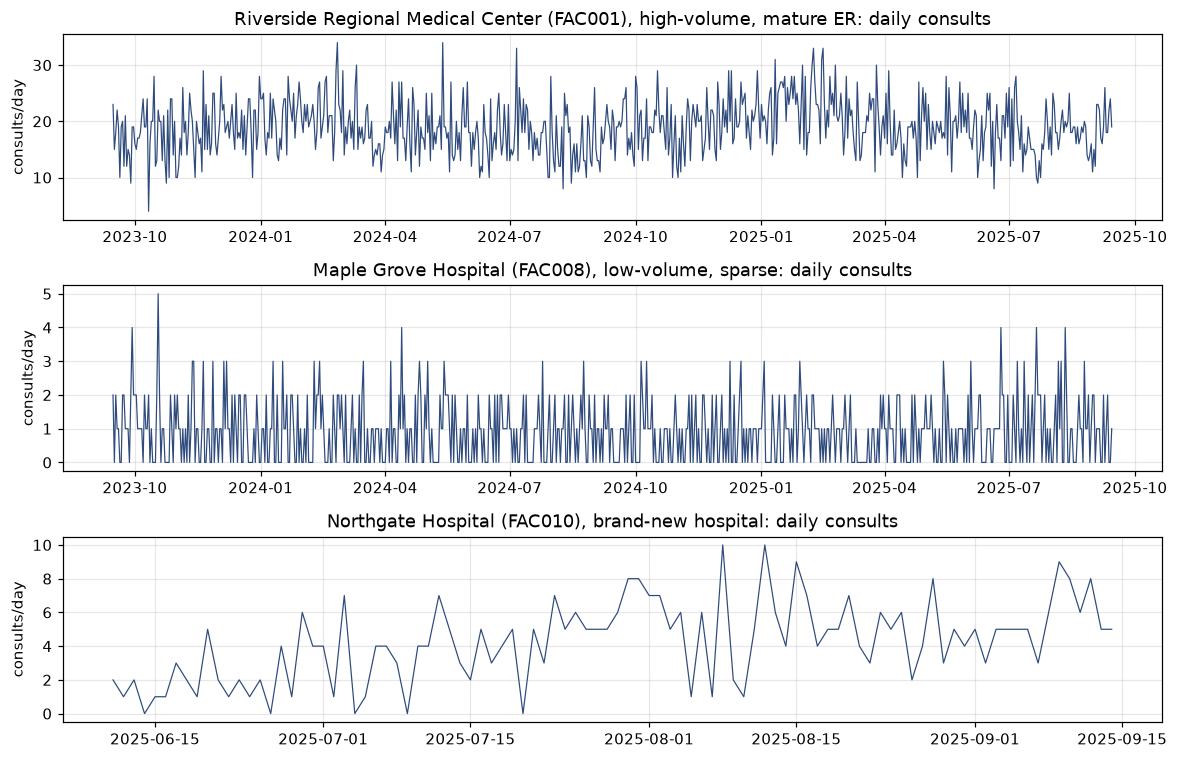

In [3]:
daily_consults = data_loader.daily_consult_counts(caselogs_local)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)
examples = [("FAC001", "high-volume, mature ER"), ("FAC008", "low-volume, sparse"), ("FAC010", "brand-new hospital")]
for ax, (fac, label) in zip(axes, examples):
    sub = daily_consults[daily_consults["facility"] == fac]
    ax.plot(pd.to_datetime(sub["local_date"]), sub["consults"], color=COLOR_HIST, linewidth=0.8)
    name = tables["facilities"].set_index("_id").loc[fac, "name"]
    ax.set_title(f"{name} ({fac}), {label}: daily consults")
    ax.set_ylabel("consults/day")
plt.tight_layout()
plt.show()


## 1. Six-month consult forecast (monthly)

Monthly, because consult volume drives a staffing/contracting decision, not a daily dispatch one, and monthly
aggregation gives a cleaner trend/seasonal signal from ~2 years of history.

Model by how much history a hospital has: Holt-Winters with yearly seasonality at 24+ months, trend-only
Holt-Winters at 8-23 months, and naive-with-drift (wide interval) below that. Rejected Prophet (no wheels for this
Python version, and monthly series this short don't need its changepoint machinery) and SARIMAX (more tuning per
hospital for the same additive trend+seasonal structure Holt-Winters already covers). A trailing partial month is
dropped before fitting so a mid-month data cutoff doesn't read as a volume crash. Intervals come from the model's
simulated forecast paths, not in-sample residuals.


In [4]:
consult_results = pipeline.run_consult_forecasts(tables, caselogs_local)

rows = []
for fac, res in consult_results.items():
    m = (res["backtest"].get("metrics") or {})
    rows.append(dict(facility=fac, tier=res["tier"], status=res["backtest"]["status"],
                      mae=m.get("mae"), mape=m.get("mape")))
pd.DataFrame(rows).sort_values("facility")


,facility,tier,status,mae,mape
0,FAC001,holt_winters_seasonal,ok,62.003970,10.265424
1,FAC002,holt_winters_seasonal,ok,7.304510,2.410022
2,FAC003,holt_winters_seasonal,ok,29.458441,14.644497
3,FAC004,holt_winters_seasonal,ok,14.421647,9.585471
4,FAC005,holt_winters_seasonal,ok,22.541443,9.190859
5,FAC006,holt_winters_seasonal,ok,7.130529,13.899007
6,FAC007,holt_winters_seasonal,ok,23.497707,17.675615
7,FAC008,holt_winters_seasonal,ok,4.729516,16.745156
8,FAC009,holt_winters_seasonal,ok,74.630807,13.585658
9,FAC010,naive_with_drift,insufficient_history,NaN,NaN


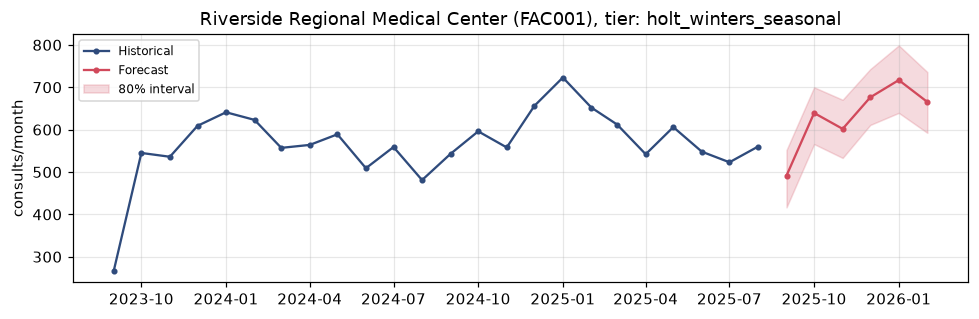

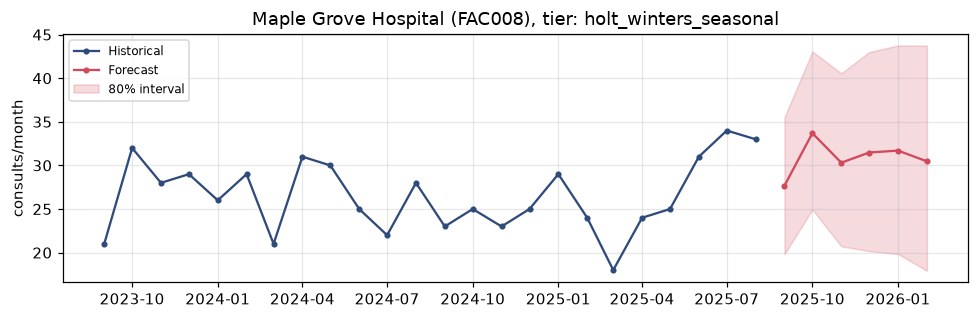

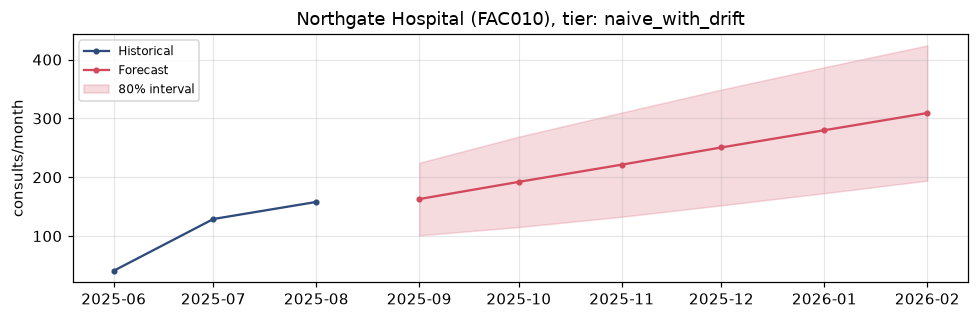

In [5]:
def plot_consult_forecast(fac):
    res = consult_results[fac]
    hist, fc = pd.DataFrame(res["history"]), pd.DataFrame(res["forecast"])
    hist["date"], fc["date"] = pd.to_datetime(hist["date"]), pd.to_datetime(fc["date"])
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(hist["date"], hist["value"], color=COLOR_HIST, marker="o", markersize=3, label="Historical")
    ax.plot(fc["date"], fc["point"], color=COLOR_FCAST, marker="o", markersize=3, label="Forecast")
    ax.fill_between(fc["date"], fc["lower"], fc["upper"], color=COLOR_FCAST, alpha=0.2, label="80% interval")
    name = tables["facilities"].set_index("_id").loc[fac, "name"]
    ax.set_title(f"{name} ({fac}), tier: {res['tier']}")
    ax.legend(fontsize=8); ax.set_ylabel("consults/month")
    plt.tight_layout(); plt.show()

for fac in ["FAC001", "FAC008", "FAC010"]:
    plot_consult_forecast(fac)


FAC001 (mature) gets a tight band, FAC008 (sparse) a wider one, and FAC010 (3 months old) the widest of all;
that's the intended behavior, not noise, since there's genuinely less to go on for the newer hospital.


## 2. Daily call forecast (60-day horizon)

Daily, since calls drive on-call scheduling directly. Holt-Winters with weekly seasonality when there's enough
volume and history (90+ days, 5+ calls/day); a day-of-week seasonal average otherwise, since Holt-Winters gets
unstable on small, mostly-zero daily counts. Neither tier models holidays explicitly, which shows up honestly in
the backtest error rather than being hidden.


In [6]:
call_results = pipeline.run_call_forecasts(tables, calls_local)

rows = []
for fac, res in call_results.items():
    m = (res["backtest"].get("metrics") or {})
    rows.append(dict(facility=fac, tier=res["tier"], status=res["backtest"]["status"],
                      mae=m.get("mae"), mape=m.get("mape")))
pd.DataFrame(rows).sort_values("facility")


,facility,tier,status,mae,mape
0,FAC001,holt_winters_weekly,ok,5.348330,15.286978
1,FAC002,holt_winters_weekly,ok,5.720905,79.770501
2,FAC003,holt_winters_weekly,ok,4.827008,52.584046
3,FAC004,holt_winters_weekly,ok,4.413189,70.613654
4,FAC005,holt_winters_weekly,ok,4.565998,37.837501
5,FAC006,dow_seasonal_average,ok,1.977943,66.896165
6,FAC007,holt_winters_weekly,ok,4.100984,52.912487
7,FAC008,dow_seasonal_average,ok,1.781890,49.741009
8,FAC009,holt_winters_weekly,ok,7.682918,22.451534
9,FAC010,holt_winters_weekly,ok,4.132594,95.992647


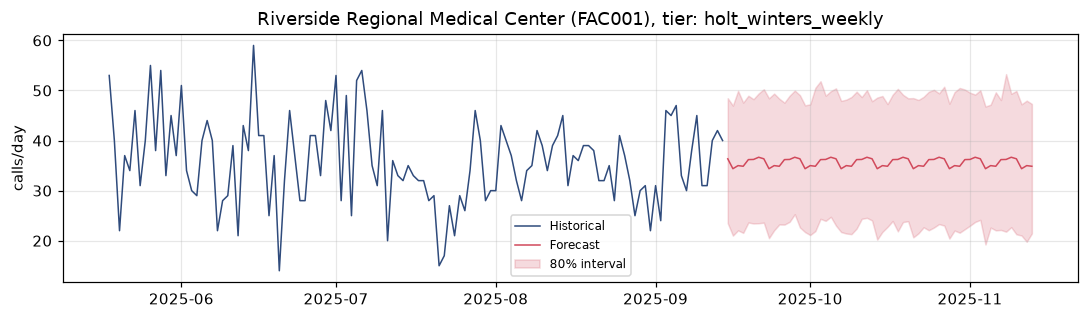

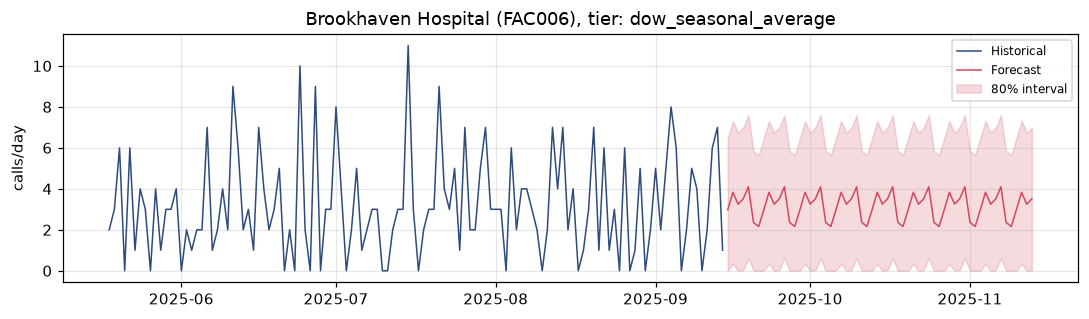

In [7]:
def plot_call_forecast(fac, days_history=120):
    res = call_results[fac]
    hist, fc = pd.DataFrame(res["history"]).tail(days_history), pd.DataFrame(res["forecast"])
    hist["date"], fc["date"] = pd.to_datetime(hist["date"]), pd.to_datetime(fc["date"])
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(hist["date"], hist["value"], color=COLOR_HIST, linewidth=1, label="Historical")
    ax.plot(fc["date"], fc["point"], color=COLOR_FCAST, linewidth=1, label="Forecast")
    ax.fill_between(fc["date"], fc["lower"], fc["upper"], color=COLOR_FCAST, alpha=0.2, label="80% interval")
    name = tables["facilities"].set_index("_id").loc[fac, "name"]
    ax.set_title(f"{name} ({fac}), tier: {res['tier']}")
    ax.legend(fontsize=8); ax.set_ylabel("calls/day")
    plt.tight_layout(); plt.show()

for fac in ["FAC001", "FAC006"]:
    plot_call_forecast(fac)


## 3. Busiest hour of day

Not a forecasting problem, a pattern-stability one: the modal local hour of historical calls, checked with a
bootstrap (resample the hours 500 times, see how often the same mode comes back) and compared across
weekday/weekend and first-half/second-half of history to catch drift.


In [8]:
busiest_hour_results = pipeline.run_busiest_hour(calls_local)

rows = []
for fac, res in busiest_hour_results.items():
    rows.append(dict(facility=fac, busiest_hour=res["overall_busiest_hour"], confidence=res["confidence"],
                      weekday=res["weekday_busiest_hour"], weekend=res["weekend_busiest_hour"],
                      drift=res["drift_flag"]))
pd.DataFrame(rows).sort_values("facility")


,facility,busiest_hour,confidence,weekday,weekend,drift
0,FAC001,2,1.000,2,2,False
1,FAC002,20,0.994,20,20,False
2,FAC003,19,0.732,18,19,True
3,FAC004,11,0.974,11,11,True
4,FAC005,0,0.646,1,0,True
5,FAC006,11,0.966,11,12,True
6,FAC007,3,0.574,4,3,True
7,FAC008,13,0.876,13,13,True
8,FAC009,21,0.976,21,21,True
9,FAC010,5,0.742,5,3,True


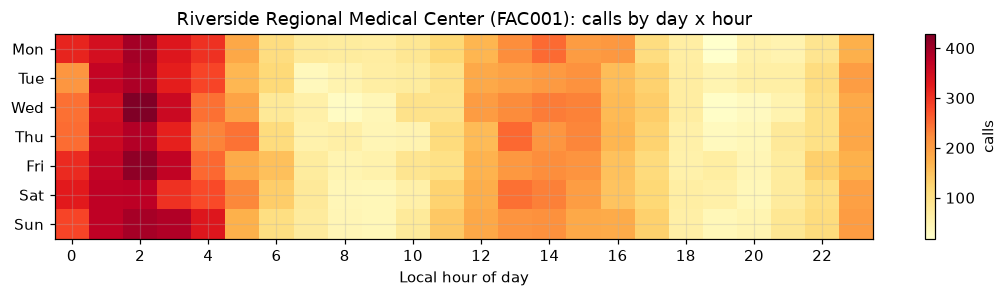

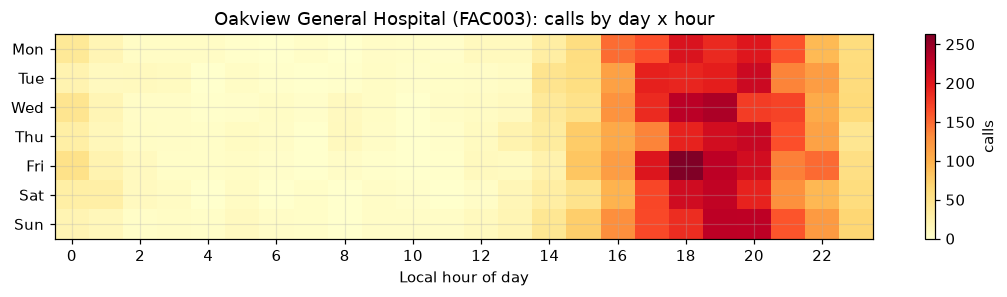

In [9]:
def plot_heatmap(fac):
    heatmap = np.array(busiest_hour_results[fac]["heatmap"])
    fig, ax = plt.subplots(figsize=(10, 2.8))
    im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(7)); ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Local hour of day")
    name = tables["facilities"].set_index("_id").loc[fac, "name"]
    ax.set_title(f"{name} ({fac}): calls by day x hour")
    plt.colorbar(im, ax=ax, label="calls")
    plt.tight_layout(); plt.show()

for fac in ["FAC001", "FAC003"]:
    plot_heatmap(fac)


FAC001 peaks sharply overnight, same hour every day (high confidence, no drift). FAC003's evening peak shifts
an hour or two later on weekends, so its busiest hour is better treated as a window than a single number.


## Limitations

- Runs on synthetic data; real seasonal shapes and hospital-to-hospital differences will differ from what's baked
  into the generator.
- No explicit holiday term in the daily call model; a SARIMAX or Prophet holiday regressor would likely tighten it.
- No pooling across hospitals for sparse/new ones; with only one synthetic new hospital there's nothing to
  validate a hierarchical approach against yet.
- `consultType`/`isStrokeAlert` aren't forecast separately, which the spec flags as useful but would roughly
  triple the number of models to maintain for this exercise's scope.
- Short-history hospitals get fewer backtest folds, so their error metrics are directional, not precise.

## Reproduce

```bash
pip install -r requirements.txt
python data/generate_synthetic_data.py
python -m src.pipeline
streamlit run app/streamlit_app.py
```
